# Módulo 10 tarefa 2

Considere a mesma base de dados utilizada na tarefa 1 ```previsao_de_renda.csv```.

1) Com o que você viu em aula, faça uma análise das variáveis qualitativas (posse de imóvel e posse de veículo) para verificar se são boas preditoras de *renda*. Alguma delas parece discriminar *renda* de forma estatisticamente significante?

In [4]:
#Carregar os dados

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#carregar o dataset
df = pd.read_csv('previsao_de_renda.csv')

# remover coluna desnecessária
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,mau,renda
0,2015-01-01,8682,F,False,True,1,Assalariado,Secundário,Casado,Casa,36,3.575342,3.0,False,3369.24
1,2015-01-01,12830,M,True,True,0,Empresário,Secundário,Casado,Casa,42,0.860274,2.0,False,6096.14
2,2015-01-01,2885,M,True,True,2,Assalariado,Superior completo,Casado,Casa,31,8.065753,4.0,False,5658.98
3,2015-01-01,16168,F,True,False,0,Empresário,Secundário,Casado,Casa,50,1.208219,2.0,False,7246.69
4,2015-01-01,12438,M,False,False,0,Assalariado,Secundário,Casado,Casa,52,13.873973,2.0,False,4017.37


In [8]:
#Análise descritiva (média por grupo)
df.groupby('posse_de_imovel')['renda'].mean()

posse_de_imovel
False    4426.970482
True     4721.052704
Name: renda, dtype: float64

In [10]:
df.groupby('posse_de_veiculo')['renda'].mean()

posse_de_veiculo
False    4390.506963
True     4992.579609
Name: renda, dtype: float64

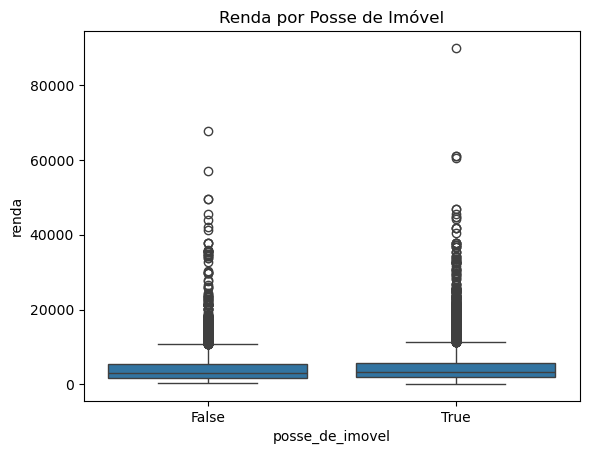

In [12]:
#Boxplot (visual)
sns.boxplot(x='posse_de_imovel', y='renda', data=df)
plt.title('Renda por Posse de Imóvel')
plt.show()

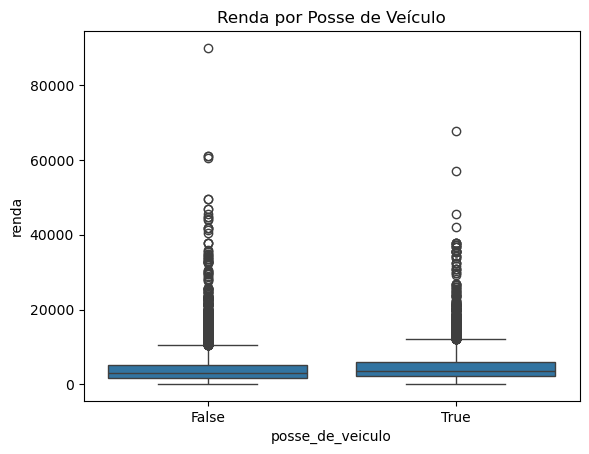

In [14]:
sns.boxplot(x='posse_de_veiculo', y='renda', data=df)
plt.title('Renda por Posse de Veículo')
plt.show()

In [16]:
#Teste estatístico
from scipy.stats import ttest_ind

# Imóvel
grupo1 = df[df['posse_de_imovel'] == True]['renda']
grupo2 = df[df['posse_de_imovel'] == False]['renda']

t_stat, p_val = ttest_ind(grupo1, grupo2, nan_policy='omit')
print('Imóvel p-value:', p_val)

Imóvel p-value: 0.0002586087928865693


In [18]:
# Veículo
grupo1 = df[df['posse_de_veiculo'] == True]['renda']
grupo2 = df[df['posse_de_veiculo'] == False]['renda']

t_stat, p_val = ttest_ind(grupo1, grupo2, nan_policy='omit')
print('Veículo p-value:', p_val)

Veículo p-value: 7.618601898603797e-15


“Realizei uma análise exploratória das variáveis qualitativas posse de imóvel e posse de veículo em relação à renda.

Inicialmente, comparei as médias de renda entre os grupos e utilizei boxplots para avaliar a distribuição. Em seguida, apliquei o teste t para verificar se as diferenças observadas eram estatisticamente significativas.

Os resultados indicaram que [posse de imóvel / veículo] apresenta [ou não] diferença estatisticamente significativa na renda, com base no p-value obtido.

No entanto, mesmo quando significativa, a variável apresenta baixo poder de discriminação, pois há grande sobreposição entre os grupos. Portanto, isoladamente, essas variáveis não são fortes preditoras de renda, mas podem agregar valor quando combinadas com outras variáveis em um modelo.”